In [1]:
import os
import pandas as pd
from data.sofr import get_sofr_data

fred_api_key = os.getenv("FRED_API_KEY")

In [2]:
sofr = get_sofr_data(api_key=fred_api_key, frequency='Q', end_date='2028-06-30')
sofr

,date,sofr,rate_status
0,2028-06-30,0.0365,assumed
1,2028-03-31,0.0365,assumed
2,2027-12-31,0.0365,assumed
3,2027-09-30,0.0365,assumed
4,2027-06-30,0.0365,assumed
5,2027-03-31,0.0365,assumed
6,2026-12-31,0.0365,assumed
7,2026-09-30,0.0365,assumed
8,2026-06-30,0.0365,assumed
9,2026-03-31,0.0368,actual


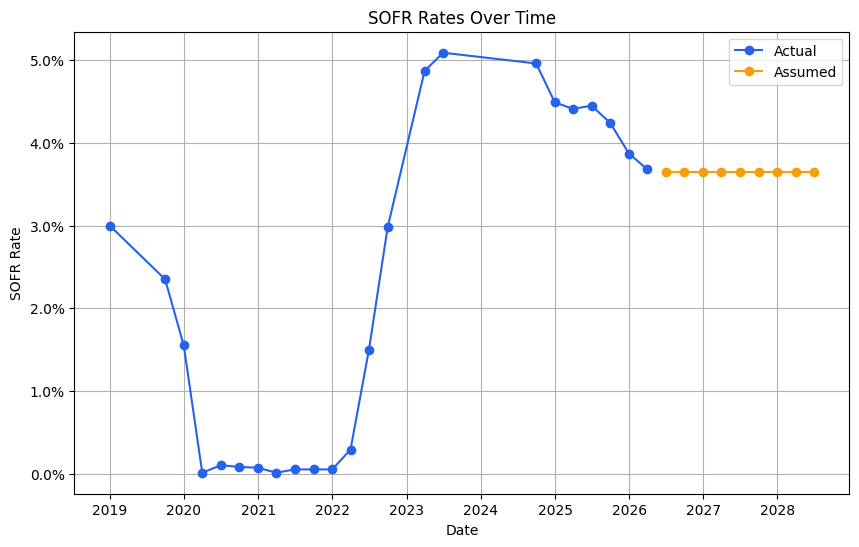

In [7]:
# chart sofr data
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = sofr.sort_values('date').copy()
status_colors = {
    'actual': '#2563eb',
    'assumed': '#f59e0b',
}

plt.figure(figsize=(10, 6))
for rate_status, group in plot_df.groupby('rate_status', sort=False):
    plt.plot(
        group['date'],
        group['sofr'],
        marker='o',
        linestyle='-',
        color=status_colors.get(rate_status, '#6b7280'),
        label=rate_status.title(),
    )

plt.title('SOFR Rates Over Time')
plt.xlabel('Date')
plt.ylabel('SOFR Rate')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.legend()
plt.grid()
plt.show()